In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv('Social_Network_Ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [27]:
df.iloc[:,2:].values

array([[   19, 19000,     0],
       [   35, 20000,     0],
       [   26, 43000,     0],
       ...,
       [   50, 20000,     1],
       [   36, 33000,     0],
       [   49, 36000,     1]], shape=(400, 3))

## Train Test Split

In [28]:
from sklearn.model_selection import train_test_split
X = df.iloc[:,2:4]
y = df.iloc[:,4]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)   
X_train.shape, X_test.shape

((300, 2), (100, 2))

## StandardScaler

In [29]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

sc.fit(X_train)
X_trainscaled = sc.transform(X_train)
X_testscaled = sc.transform(X_test)


In [35]:
X_train

,Age,EstimatedSalary
250,44,39000
63,32,120000
312,38,50000
159,32,135000
283,52,21000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [40]:
X_trainscaled

,Age,EstimatedSalary
0,0.581649,-0.886707
1,-0.606738,1.461738
2,-0.012544,-0.567782
3,-0.606738,1.896635
4,1.373907,-1.408584
...,...,...
295,0.977778,-1.147645
296,-0.903834,-0.770734
297,-0.210609,-0.509796
298,-1.101899,-0.451810


In [41]:
# to convert the numpy array to a dataframe
X_trainscaled = pd.DataFrame(X_trainscaled, columns=['Age', 'EstimatedSalary'])
X_testscaled = pd.DataFrame(X_testscaled, columns=['Age', 'EstimatedSalary'])

In [44]:
np.round(X_trainscaled.describe(), 2)

,Age,EstimatedSalary
count,300.00,300.00
mean,0.00,0.00
std,1.00,1.00
min,-1.99,-1.58
25%,-0.73,-0.77
50%,-0.01,-0.00
75%,0.78,0.53
max,2.17,2.33


In [45]:
np.round(X_train.describe(), 2)  

,Age,EstimatedSalary
count,300.00,300.00
mean,38.13,69583.33
std,10.11,34548.54
min,18.00,15000.00
25%,30.75,43000.00
50%,38.00,69500.00
75%,46.00,88000.00
max,60.00,150000.00


Text(0.5, 1.0, 'After Scaling')

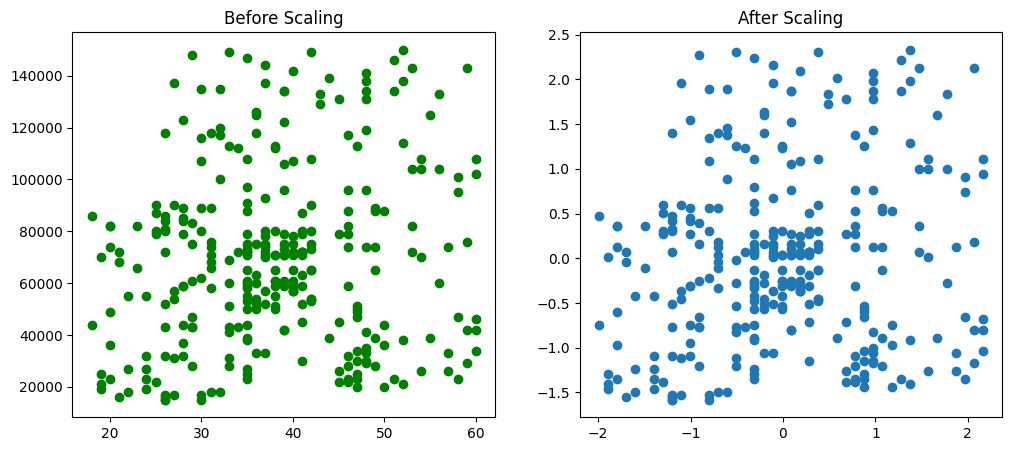

In [52]:
fig, (ax1, ax2) = plt.subplots(ncols =2, figsize=(12,5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'],color='green')
ax1.set_title('Before Scaling')
ax2.scatter(X_trainscaled['Age'], X_trainscaled['EstimatedSalary'])
ax2.set_title('After Scaling')

Text(0.5, 1.0, 'After Scaling')

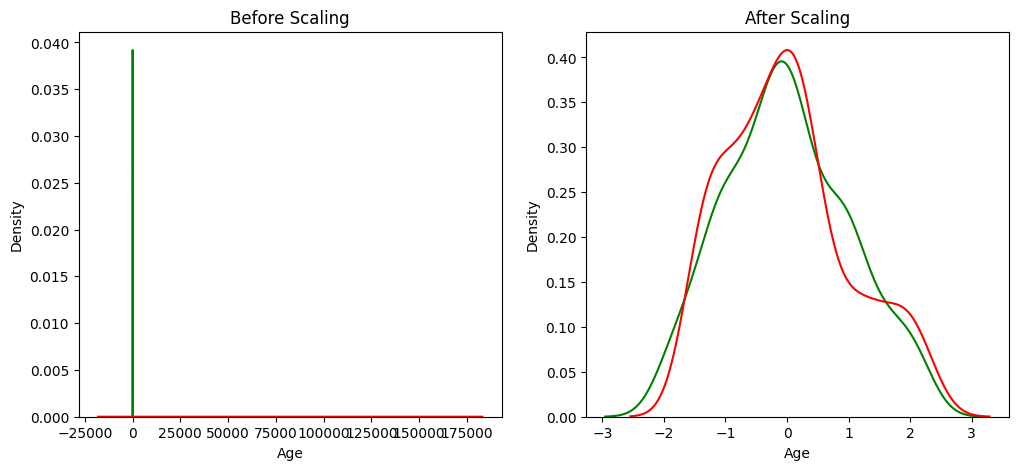

In [54]:
fig, (ax1, ax2) = plt.subplots(ncols =2, figsize=(12,5))

sns.kdeplot(X_train['Age'], ax=ax1, color='green')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1, color='red')
ax1.set_title('Before Scaling')
sns.kdeplot(X_trainscaled['Age'], ax=ax2, color='green')
sns.kdeplot(X_trainscaled['EstimatedSalary'], ax=ax2, color='red')
ax2.set_title('After Scaling')

### why scaling is important??


In [55]:
from sklearn.linear_model import LogisticRegression

In [56]:
lr = LogisticRegression()
lrscale = LogisticRegression()

lr.fit(X_train, y_train)
lrscale.fit(X_trainscaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [57]:
y_pred = lr.predict(X_test)
y_predscale = lrscale.predict(X_testscaled)

In [ ]:
from sklearn.metrics import accuracy_score

In [59]:
print('Accuracy of Logistic Regression without Scaling:', accuracy_score(y_test, y_pred))
print('Accuracy of Logistic Regression with Scaling:', accuracy_score(y_test, y_predscale))

Accuracy of Logistic Regression without Scaling: 0.89
Accuracy of Logistic Regression with Scaling: 0.89
